In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os

In [2]:
import cv2
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


In [3]:
main_path = "Dataset/Grape"

In [4]:
img_list=[]
label_list=[]
for folder in os.listdir(main_path):
    folder_path=os.path.join(main_path,folder)
    for filename in os.listdir(folder_path):
        img_path=os.path.join(folder_path,filename)
        img_list.append(img_path)
        label_list.append(folder)

In [5]:
df=pd.DataFrame({'img':img_list,'label':label_list})

In [6]:
df.sample(5)

,img,label
9307,Dataset/Grape\Leaf Blight\2f24f635-8959-4d9f-b...,Leaf Blight
238,Dataset/Grape\Black Rot\2011a0a0-a9f9-4be8-9a2...,Black Rot
9086,Dataset/Grape\Leaf Blight\0e4eb45c-721c-49ee-8...,Leaf Blight
8265,Dataset/Grape\Healthy\_206_8542128.png,Healthy
8211,Dataset/Grape\Healthy\_1578_9275349.png,Healthy


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   img     12000 non-null  object
 1   label   12000 non-null  object
dtypes: object(2)
memory usage: 187.6+ KB


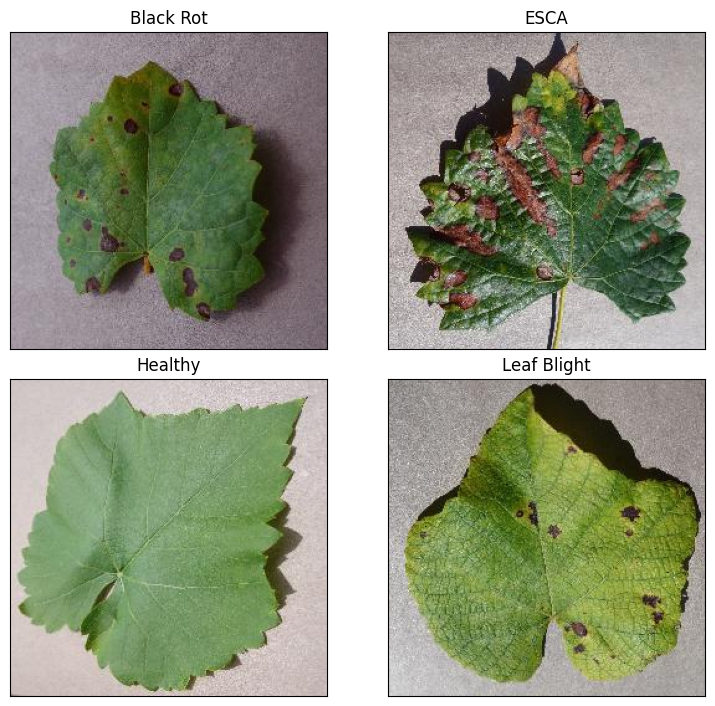

In [8]:
df_unique = df.copy().drop_duplicates(subset=["label"]).reset_index()

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 7),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):
    ax.imshow(plt.imread(df_unique['img'][i]))
    ax.set_title(df_unique['label'][i], fontsize = 12)
plt.tight_layout(pad=0.5)
plt.show()

In [9]:
df['label'].value_counts()


label
Black Rot      3000
ESCA           3000
Healthy        3000
Leaf Blight    3000
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

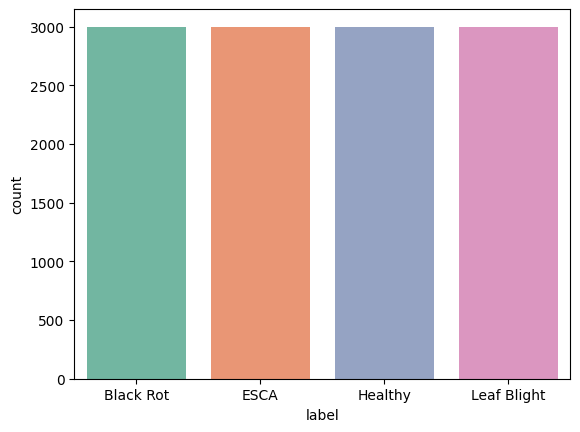

In [10]:
sns.countplot(x='label',data=df,palette='Set2')


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['encode_label'] = encoder.fit_transform(df['label'])

In [12]:
df.sample(5)

,img,label,encode_label
7442,Dataset/Grape\Healthy\d61f8828-71c9-4f3d-85e7-...,Healthy,2
1298,Dataset/Grape\Black Rot\b055115b-4eb8-4126-9db...,Black Rot,0
6685,Dataset/Grape\Healthy\63a683df-44e9-410f-b04c-...,Healthy,2
891,Dataset/Grape\Black Rot\7d2ddc15-ef09-49e7-95c...,Black Rot,0
10074,Dataset/Grape\Leaf Blight\9ce5ffd2-5d1d-4bb2-a...,Leaf Blight,3


In [13]:
label_dict = dict(zip(df['encode_label'], df['label']))
sorted_label_dict = dict(sorted(label_dict.items()))
output = ',\n'.join([f"{key}:'{value}'" for key, value in sorted_label_dict.items()])

print(output)

0:'Black Rot',
1:'ESCA',
2:'Healthy',
3:'Leaf Blight'


In [14]:
x=[]
for img in df['img']:
    img=cv2.imread(img)
    img=cv2.resize(img,(170,170)) #We resized the image to 32x32 pixels.
    img=img/255.0 #normalize the data
    x.append(img)

In [15]:
x=np.array(x)

In [16]:
y=df['encode_label']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
from keras.models import Sequential
from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D,Dropout,BatchNormalization,Reshape

In [20]:
model = Sequential()
model.add(Input(shape=(170,170,3)))
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(4, activation='softmax'))
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
history = model.fit(x_train,y_train,epochs=10,validation_data=(x_test,y_test),verbose=1)

Epoch 1/10
300/300 [==============================] - 244s 805ms/step - loss: 0.4574 - accuracy: 0.8410 - val_loss: 0.2040 - val_accuracy: 0.9362
Epoch 2/10
300/300 [==============================] - 196s 651ms/step - loss: 0.1427 - accuracy: 0.9472 - val_loss: 0.1901 - val_accuracy: 0.9279
Epoch 3/10
300/300 [==============================] - 184s 615ms/step - loss: 0.0691 - accuracy: 0.9754 - val_loss: 0.1637 - val_accuracy: 0.9429
Epoch 4/10
300/300 [==============================] - 185s 616ms/step - loss: 0.0343 - accuracy: 0.9894 - val_loss: 0.1945 - val_accuracy: 0.9400
Epoch 5/10
300/300 [==============================] - 192s 638ms/step - loss: 0.0539 - accuracy: 0.9843 - val_loss: 0.0965 - val_accuracy: 0.9683
Epoch 6/10
300/300 [==============================] - 220s 732ms/step - loss: 0.0070 - accuracy: 0.9984 - val_loss: 0.0859 - val_accuracy: 0.9733
Epoch 7/10
300/300 [==============================] - 214s 715ms/step - loss: 8.0642e-04 - accuracy: 1.0000 - val_loss: 0.07

In [22]:
model.save('grape_disease_model.h5')

In [23]:
# from keras.models import Sequential
# from keras.layers import Conv2D, Dense, Flatten, Input, MaxPooling2D,Dropout,BatchNormalization,Reshape
# from tensorflow.keras.applications import VGG16,ResNet50
# from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

data_dir = "Dataset/Grape"
img_width, img_height = 224, 224

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(img_width, img_height),
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    directory=data_dir,
    target_size=(img_width, img_height),
    class_mode='categorical',
    subset='validation'
)

base_model = VGG16(
    weights='imagenet',
    input_shape=(img_width, img_height, 3),
    include_top=False
)
base_model.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dense(1024, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)


Found 9600 images belonging to 4 classes.
Found 2400 images belonging to 4 classes.
58889256/58889256 [==============================] - 11s 0us/step
Epoch 1/10
300/300 [==============================] - 4150s 14s/step - loss: 0.4306 - accuracy: 0.9079 - val_loss: 0.0959 - val_accuracy: 0.9613
Epoch 2/10
300/300 [==============================] - 2635s 9s/step - loss: 0.0479 - accuracy: 0.9817 - val_loss: 0.0844 - val_accuracy: 0.9721
Epoch 3/10
300/300 [==============================] - 2795s 9s/step - loss: 0.0451 - accuracy: 0.9842 - val_loss: 0.1592 - val_accuracy: 0.9488
Epoch 4/10
163/300 [===============>..............] - ETA: 16:41 - loss: 0.0515 - accuracy: 0.9827

In [ ]:
model.save('grape_disease_tf_model.h5')